In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy

In [ ]:
x_text = """6.1101  5.5277  8.5186  7.0032  5.8598  8.3829  7.4764  8.5781  6.4862
  5.0546  5.7107 14.164   5.734   8.4084  5.6407  5.3794  6.3654  5.1301
  6.4296  7.0708  6.1891 20.27    5.4901  6.3261  5.5649 18.945  12.828
 10.957  13.176  22.203   5.2524  6.5894  9.2482  5.8918  8.2111  7.9334
  8.0959  5.6063 12.836   6.3534  5.4069  6.8825 11.708   5.7737  7.8247
  7.0931  5.0702  5.8014 11.7     5.5416  7.5402  5.3077  7.4239  7.6031
  6.3328  6.3589  6.2742  5.6397  9.3102  9.4536  8.8254  5.1793 21.279
 14.908  18.959   7.2182  8.2951 10.236   5.4994 20.341  10.136   7.3345
  6.0062  7.2259  5.0269  6.5479  7.5386  5.0365 10.274   5.1077  5.7292
  5.1884  6.3557  9.7687  6.5159  8.5172  9.1802  6.002   5.5204  5.0594
  5.7077  7.6366  5.8707  5.3054  8.2934 13.394   5.4369"""

In [ ]:
x_train = np.fromstring(x_text , sep= ' ')
print(x_train)
print(type(x_train))

[ 6.1101  5.5277  8.5186  7.0032  5.8598  8.3829  7.4764  8.5781  6.4862
  5.0546  5.7107 14.164   5.734   8.4084  5.6407  5.3794  6.3654  5.1301
  6.4296  7.0708  6.1891 20.27    5.4901  6.3261  5.5649 18.945  12.828
 10.957  13.176  22.203   5.2524  6.5894  9.2482  5.8918  8.2111  7.9334
  8.0959  5.6063 12.836   6.3534  5.4069  6.8825 11.708   5.7737  7.8247
  7.0931  5.0702  5.8014 11.7     5.5416  7.5402  5.3077  7.4239  7.6031
  6.3328  6.3589  6.2742  5.6397  9.3102  9.4536  8.8254  5.1793 21.279
 14.908  18.959   7.2182  8.2951 10.236   5.4994 20.341  10.136   7.3345
  6.0062  7.2259  5.0269  6.5479  7.5386  5.0365 10.274   5.1077  5.7292
  5.1884  6.3557  9.7687  6.5159  8.5172  9.1802  6.002   5.5204  5.0594
  5.7077  7.6366  5.8707  5.3054  8.2934 13.394   5.4369]
<class 'numpy.ndarray'>


In [ ]:
y_text = """17.592    9.1302  13.662   11.854    6.8233  11.886    4.3483  12.
  6.5987   3.8166   3.2522  15.505    3.1551   7.2258   0.71618  3.5129
  5.3048   0.56077  3.6518   5.3893   3.1386  21.767    4.263    5.1875
  3.0825  22.638   13.501    7.0467  14.692   24.147   -1.22     5.9966
 12.134    1.8495   6.5426   4.5623   4.1164   3.3928  10.117    5.4974
  0.55657  3.9115   5.3854   2.4406   6.7318   1.0463   5.1337   1.844
  8.0043   1.0179   6.7504   1.8396   4.2885   4.9981   1.4233  -1.4211
  2.4756   4.6042   3.9624   5.4141   5.1694  -0.74279 17.929   12.054
 17.054    4.8852   5.7442   7.7754   1.0173  20.992    6.6799   4.0259
  1.2784   3.3411  -2.6807   0.29678  3.8845   5.7014   6.7526   2.0576
  0.47953  0.20421  0.67861  7.5435   5.3436   4.2415   6.7981   0.92695
  0.152    2.8214   1.8451   4.2959   7.2029   1.9869   0.14454  9.0551
  0.61705"""

In [ ]:
y_train = np.fromstring(y_text , sep = " ")
print(type(y_train))
print(type(y_train[0]))
print(y_train)

<class 'numpy.ndarray'>
<class 'numpy.float64'>
[17.592    9.1302  13.662   11.854    6.8233  11.886    4.3483  12.
  6.5987   3.8166   3.2522  15.505    3.1551   7.2258   0.71618  3.5129
  5.3048   0.56077  3.6518   5.3893   3.1386  21.767    4.263    5.1875
  3.0825  22.638   13.501    7.0467  14.692   24.147   -1.22     5.9966
 12.134    1.8495   6.5426   4.5623   4.1164   3.3928  10.117    5.4974
  0.55657  3.9115   5.3854   2.4406   6.7318   1.0463   5.1337   1.844
  8.0043   1.0179   6.7504   1.8396   4.2885   4.9981   1.4233  -1.4211
  2.4756   4.6042   3.9624   5.4141   5.1694  -0.74279 17.929   12.054
 17.054    4.8852   5.7442   7.7754   1.0173  20.992    6.6799   4.0259
  1.2784   3.3411  -2.6807   0.29678  3.8845   5.7014   6.7526   2.0576
  0.47953  0.20421  0.67861  7.5435   5.3436   4.2415   6.7981   0.92695
  0.152    2.8214   1.8451   4.2959   7.2029   1.9869   0.14454  9.0551
  0.61705]


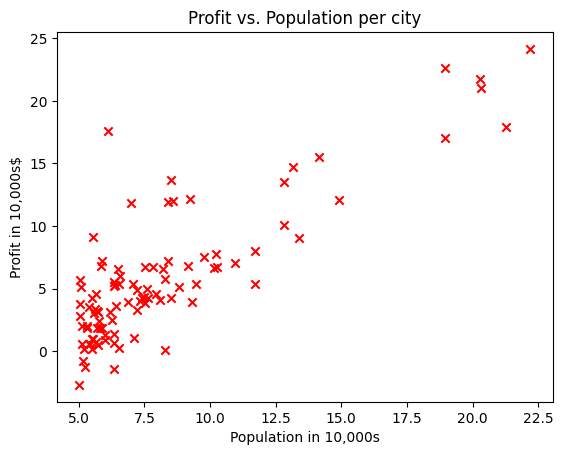

In [ ]:
plt.scatter(x_train , y_train, marker='x' , c='r')
plt.title("Profit vs. Population per city")
plt.xlabel("Population in 10,000s")
plt.ylabel("Profit in 10,000s$")
plt.show()

In [ ]:
# Compute cost

def compute_cost(x,y,w,b):
  total_cost = 0
  m = x.shape[0]
  for i in range(m):
    f_wb = np.dot(w, x[i]) + b
    cost = (f_wb - y[i]) ** 2
    total_cost = total_cost + cost
  total_cost = total_cost/(2 * m)
  return total_cost

In [ ]:
w_in = 0
b_in = 0

In [ ]:
cost = compute_cost(x_train , y_train , w_in , b_in)
print(cost)

32.072733877455654


In [ ]:
# Compute Gradient to calculate the derivative w.r.t w and b

def compute_gradient(x,y,w,b):
  dj_dw = 0
  dj_db = 0
  m = x.shape[0]
  for i in range(m):
    f_wb = np.dot(w , x[i]) + b
    error = (f_wb - y[i])
    dj_dw_i = error * x[i]
    dj_db_i = error

    dj_dw = dj_dw + dj_dw_i
    dj_db = dj_db + dj_db_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw , dj_db


In [ ]:
dw , db = compute_gradient(x_train, y_train , w_in , b_in)
print(dw)
print(db)

-65.32884974555672
-5.83913505154639


In [ ]:
# Gradient descent
def gradient_descent(x, y, w_in, b_in, alpha, iters, cost_fun, compute_gradient_fun):

  cost_hist = []
  wb_history = []
  w = copy.deepcopy(w_in)
  b = b_in

  for i in range(iters):
    dj_dw, dj_db = compute_gradient_fun(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i <= 10000:
      cost_hist.append(cost_fun(x,y,w,b))

    if i % math.ceil(iters/10) == 0:
      wb_history.append((w,b))
      print(f"Iterations: {i : 4}: Cost: {cost_hist[-1]:8.2f}")

  return w, b, cost_hist, wb_history


In [ ]:
w_in = 0
b_in = 0
iters = 15000
alpha = 0.01

In [ ]:
w_final, b_final , cost_history, parameters_history = gradient_descent(x_train, y_train, w_in , b_in , alpha , iters, compute_cost , compute_gradient)

print(w_final)
print(b_final)
print(parameters_history[:10])
print(cost_history[:10])

Iterations:    0: Cost:     6.74
Iterations:  1500: Cost:     4.48
Iterations:  3000: Cost:     4.48
Iterations:  4500: Cost:     4.48
Iterations:  6000: Cost:     4.48
Iterations:  7500: Cost:     4.48
Iterations:  9000: Cost:     4.48
Iterations:  10500: Cost:     4.48
Iterations:  12000: Cost:     4.48
Iterations:  13500: Cost:     4.48
1.1930336441888891
-3.8957808783048415
[(np.float64(0.6532884974555673), np.float64(0.0583913505154639)), (np.float64(1.166410427898432), np.float64(-3.6307700095575353)), (np.float64(1.1912557138634143), np.float64(-3.878083134539182)), (np.float64(1.1929149118692695), np.float64(-3.894599001749149)), (np.float64(1.1930257151027888), np.float64(-3.895701951176995)), (np.float64(1.1930331146756639), np.float64(-3.8957756074630967)), (np.float64(1.193033608828018), np.float64(-3.8957805263182483)), (np.float64(1.1930336418281053), np.float64(-3.8957808548052997)), (np.float64(1.1930336440318905), np.float64(-3.8957808767420583)), (np.float64(1.1930336

In [ ]:
# Now make prediction

m = x_train.shape[0]
prediction = np.zeros(m)

for i in range(m):
  prediction[i] = np.dot(w_final, x_train[i]) + b_final

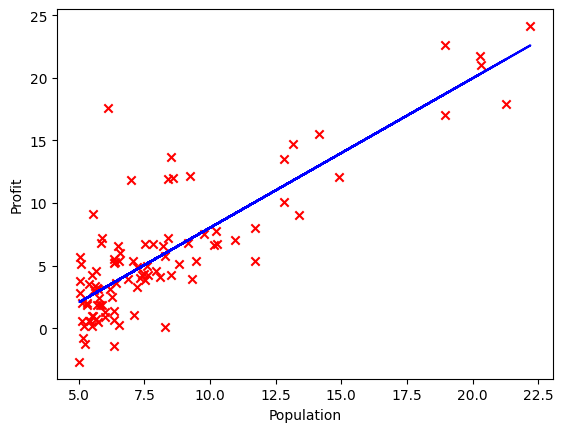

In [ ]:
plt.scatter(x_train , y_train , label = "Actual Data", c = 'r' , marker = 'x')
plt.plot(x_train , prediction , label = "Model Prediction" , c = 'b')
plt.xlabel("Population")
plt.ylabel("Profit")
plt.show()

In [ ]:
# New Predictions

predict1 = w_final * 3.5 + b_final
print(predict1)

0.27983687635627064
